<a href="https://colab.research.google.com/github/nibaskumar93n-debug/Morphoinformatics/blob/main/ashik_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ── CELL 1: Install packages ──────────────────────────────────────────────────
!pip install -q pandas numpy matplotlib scipy seaborn openpyxl
print("✅ All packages installed!")

✅ All packages installed!


In [6]:
# ── CELL 2: Upload and load your Excel file ───────────────────────────────────
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_excel(filename)   # ← fix: read_excel not read_csv

print(f"✅ File loaded: {filename}")
print(f"   Shape: {df.shape}")
print(f"   Columns: {df.columns.tolist()}")
print(df.head())

Saving Health Risk Analysis (1).xlsx to Health Risk Analysis (1).xlsx
✅ File loaded: Health Risk Analysis (1).xlsx
   Shape: (40, 14)
   Columns: ['sample', 'Latitude ', 'Longitude', 'Ni', 'V', 'Co', 'Cd', 'Fe', 'Mn', 'As', 'Zn', ' Pb', 'Cr', 'Cu']
  sample   Latitude    Longitude    Ni     V    Co        Cd        Fe  \
0  ASA-1  22°31'22"N  89°09'14"E  32.1  63.8  51.4  0.170000  27946.15   
1  ASA-2  22°30'38"N  89°09'20"E  38.1  68.8  58.4  1.856698  32341.50   
2  ASA-3  22°30'18"N  89°09'29"E  38.9  73.8  61.1  1.000000  33942.60   
3  ASA-4  22°29'50"N  89°09'20"E  36.5  63.8  55.6  0.060000  28941.75   
4  ASA-5  22°29'23"N  89°09'35"E  36.5  68.8  57.0  1.868774  34847.50   

           Mn        As         Zn         Pb          Cr    Cu  
0  596.548125  7.902725  84.850000  30.000000  121.113281  51.7  
1  638.338235  7.202664  66.887868  37.443623  149.509688  59.1  
2  492.063158  7.325786  77.447368  45.091421  179.843906  58.3  
3  619.801875  7.873208  72.493750  31.396

In [12]:
# ── CELL 3: Clean columns, set sample column, and extract metals ─────────────

# 1. Clean ALL column names (critical fix)
df.columns = df.columns.str.strip()

# 2. Standardize sample column
df = df.rename(columns={'sample': 'Sample'})

# 3. Define metals
metals = ['Ni', 'V', 'Co', 'Cd', 'Fe', 'Mn', 'As', 'Zn', 'Pb', 'Cr', 'Cu']

# 4. Check for missing columns (defensive programming)
missing = [m for m in metals if m not in df.columns]
if missing:
    print(f"⚠️ Missing columns detected: {missing}")

# 5. Zone classification from sample name
df['Zone'] = df['Sample'].apply(
    lambda x: 'ASA' if str(x).startswith('ASA') else
              'ND'  if str(x).startswith('ND')  else 'DUM'
)

# 6. Ensure metals are numeric
for m in metals:
    if m in df.columns:
        df[m] = pd.to_numeric(df[m], errors='coerce')

# 7. Output
print(f"✅ Metals extracted: {metals}")
print(f"   Zones: {df['Zone'].value_counts().to_dict()}")
print(df[['Sample','Zone'] + metals].head(5).to_string(index=False))

✅ Metals extracted: ['Ni', 'V', 'Co', 'Cd', 'Fe', 'Mn', 'As', 'Zn', 'Pb', 'Cr', 'Cu']
   Zones: {'ASA': 20, 'ND': 10, 'DUM': 10}
Sample Zone   Ni    V   Co       Cd       Fe         Mn       As        Zn        Pb         Cr   Cu
 ASA-1  ASA 32.1 63.8 51.4 0.170000 27946.15 596.548125 7.902725 84.850000 30.000000 121.113281 51.7
 ASA-2  ASA 38.1 68.8 58.4 1.856698 32341.50 638.338235 7.202664 66.887868 37.443623 149.509688 59.1
 ASA-3  ASA 38.9 73.8 61.1 1.000000 33942.60 492.063158 7.325786 77.447368 45.091421 179.843906 58.3
 ASA-4  ASA 36.5 63.8 55.6 0.060000 28941.75 619.801875 7.873208 72.493750 31.396226 125.585156 57.3
 ASA-5  ASA 36.5 68.8 57.0 1.868774 34847.50 644.476103 7.647799 81.590074 37.826818 150.987891 55.5


In [13]:
# ── CELL 4: Background values and guidelines ──────────────────────────────────
background = {
    'Ni': 68,   'V': 130,  'Co': 19,   'Cd': 0.3,
    'Fe': 47200,'Mn': 850, 'As': 13,   'Zn': 95,
    'Pb': 20,   'Cr': 90,  'Cu': 45
}

who_guideline = {
    'Ni': 35,    'V': 120,   'Co': 50,   'Cd': 3,
    'Fe': 50000, 'Mn': 500,  'As': 20,   'Zn': 200,
    'Pb': 85,    'Cr': 100,  'Cu': 63
}

print("✅ Background values (Turekian & Wedepohl 1961; As: Wedepohl 1995):")
for m in metals:
    print(f"   {m:4s}: background = {background[m]:<8} WHO = {who_guideline[m]}")

✅ Background values (Turekian & Wedepohl 1961; As: Wedepohl 1995):
   Ni  : background = 68       WHO = 35
   V   : background = 130      WHO = 120
   Co  : background = 19       WHO = 50
   Cd  : background = 0.3      WHO = 3
   Fe  : background = 47200    WHO = 50000
   Mn  : background = 850      WHO = 500
   As  : background = 13       WHO = 20
   Zn  : background = 95       WHO = 200
   Pb  : background = 20       WHO = 85
   Cr  : background = 90       WHO = 100
   Cu  : background = 45       WHO = 63


In [15]:
# ── CELL 5: Descriptive statistics ───────────────────────────────────────────
import numpy as np
from scipy import stats

rows = []
for m in metals:
    v = df[m].dropna().values

    rows.append({
        'Metal'          : m,
        'n'              : len(v),
        'Min'            : round(v.min(), 3),
        'Max'            : round(v.max(), 3),
        'Mean'           : round(v.mean(), 3),
        'Median'         : round(np.median(v), 3),   # now works ✅
        'Std'            : round(v.std(), 3),
        'CV(%)'          : round(v.std()/v.mean()*100, 2),
        'Skewness'       : round(stats.skew(v), 3),
        'Kurtosis'       : round(stats.kurtosis(v), 3),
        'Background'     : background[m],
        'Mean/Background': round(v.mean()/background[m], 3)
    })

stats_df = pd.DataFrame(rows)

print("✅ Descriptive statistics:")
print(stats_df.to_string(index=False))

stats_df.to_excel('descriptive_statistics.xlsx', index=False)
print("\n✅ Saved: descriptive_statistics.xlsx")

✅ Descriptive statistics:
Metal  n       Min       Max      Mean    Median      Std  CV(%)  Skewness  Kurtosis  Background  Mean/Background
   Ni 40    28.700    50.900    42.050    41.350    5.851  13.91    -0.129    -1.126        68.0            0.618
    V 40    63.800    90.800    78.425    79.800   10.428  13.30    -0.127    -1.632       130.0            0.603
   Co 40    45.700    69.100    58.958    58.850    6.003  10.18    -0.222    -0.610        19.0            3.103
   Cd 40     0.060     2.032     1.289     1.565    0.634  49.20    -0.682    -0.972         0.3            4.296
   Fe 40 22375.800 56664.600 38243.382 36854.750 8523.893  22.29     0.492    -0.485     47200.0            0.810
   Mn 40   375.324   934.920   638.282   629.351  135.123  21.17     0.222    -0.166       850.0            0.751
   As 40     5.491    11.721     8.071     7.888    1.393  17.26     0.228    -0.218        13.0            0.621
   Zn 40    50.433   105.769    75.308    72.637   13.902  18.

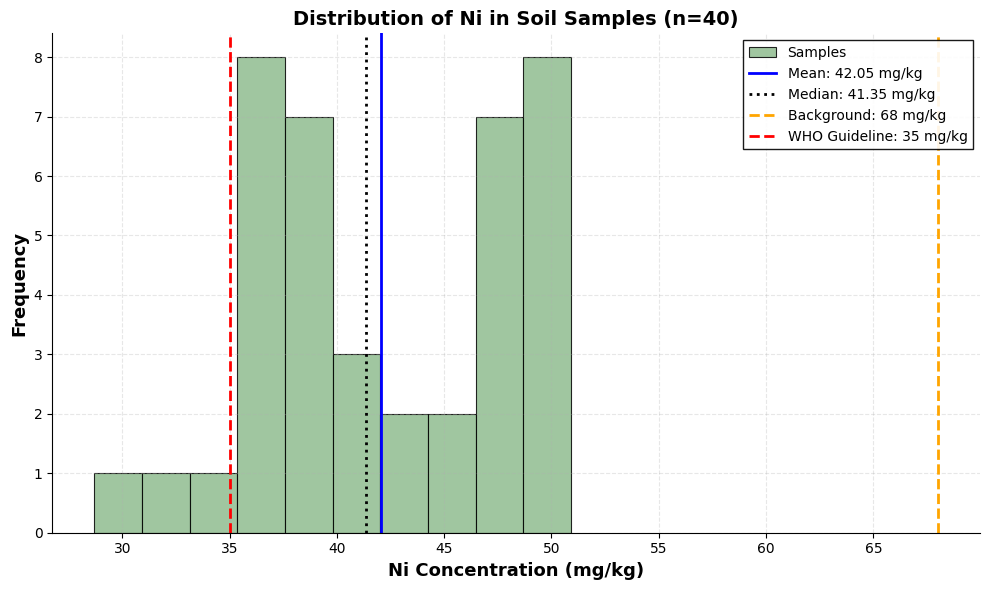

✅ Saved: distribution_Ni.svg


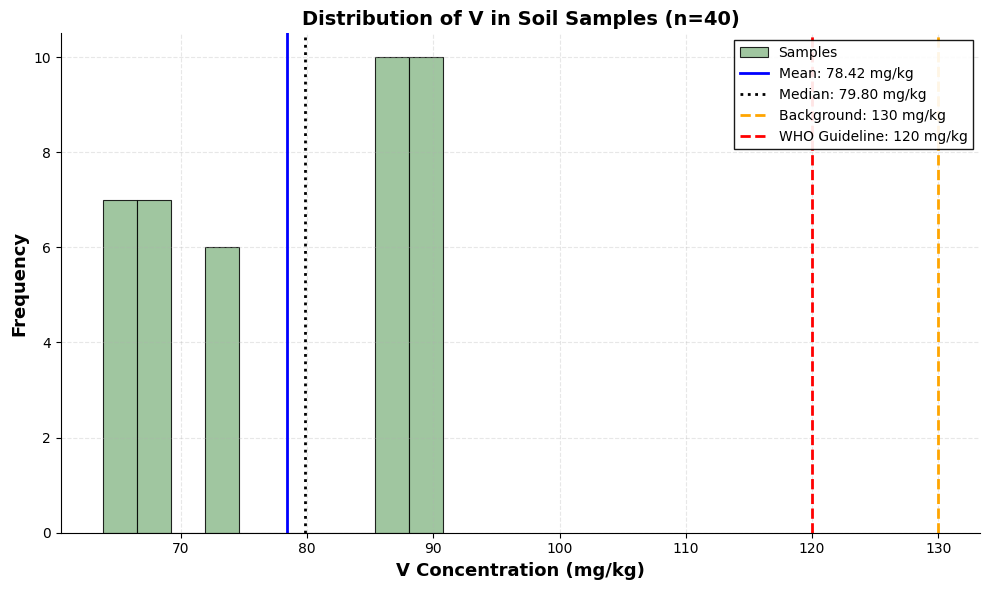

✅ Saved: distribution_V.svg


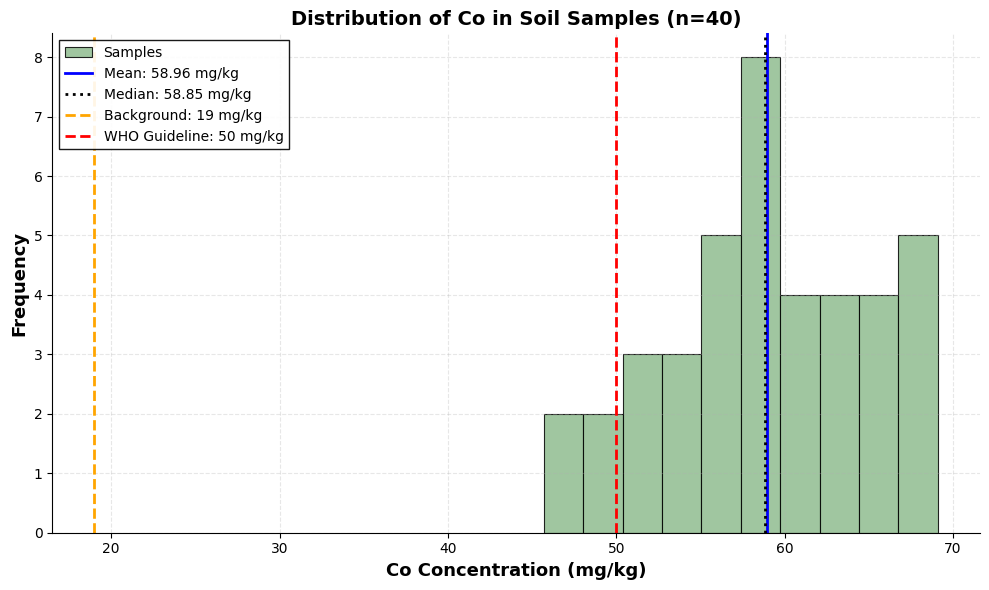

✅ Saved: distribution_Co.svg


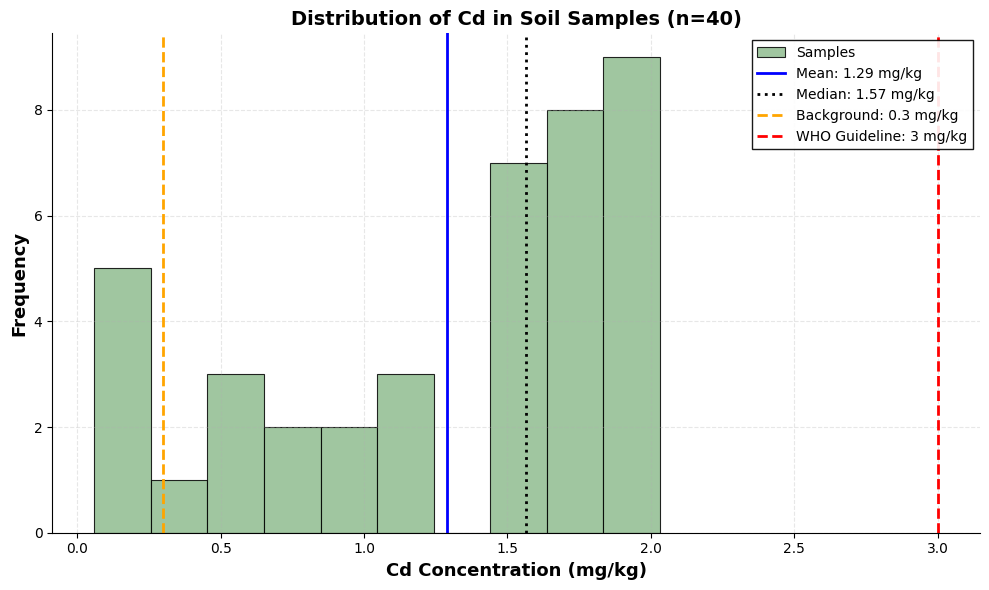

✅ Saved: distribution_Cd.svg


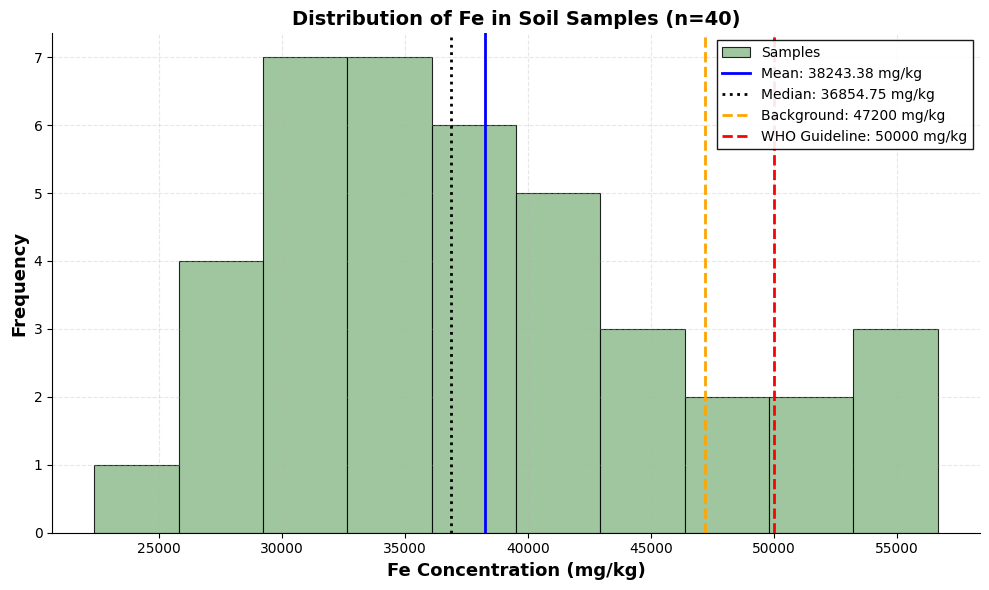

✅ Saved: distribution_Fe.svg


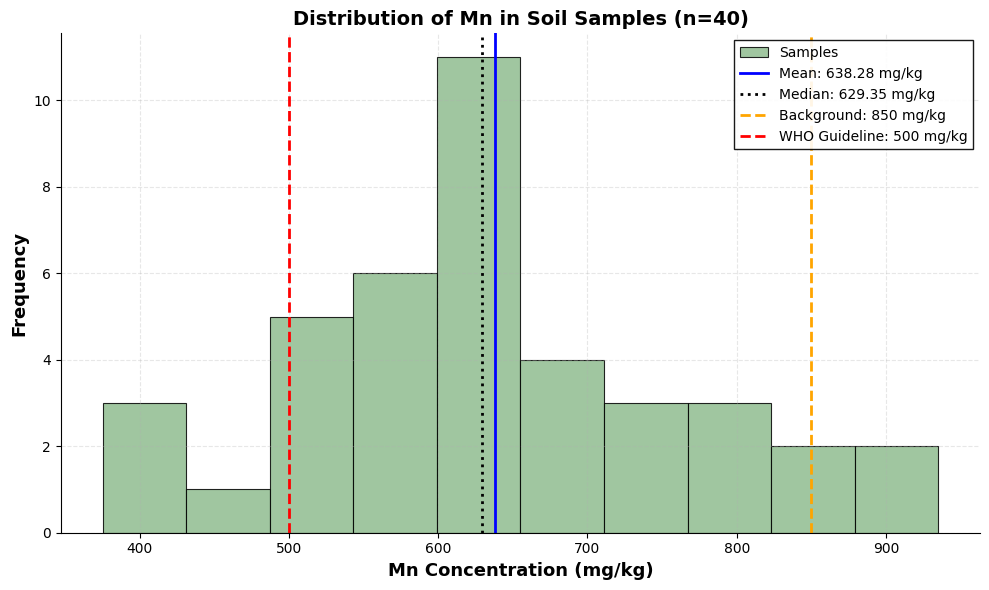

✅ Saved: distribution_Mn.svg


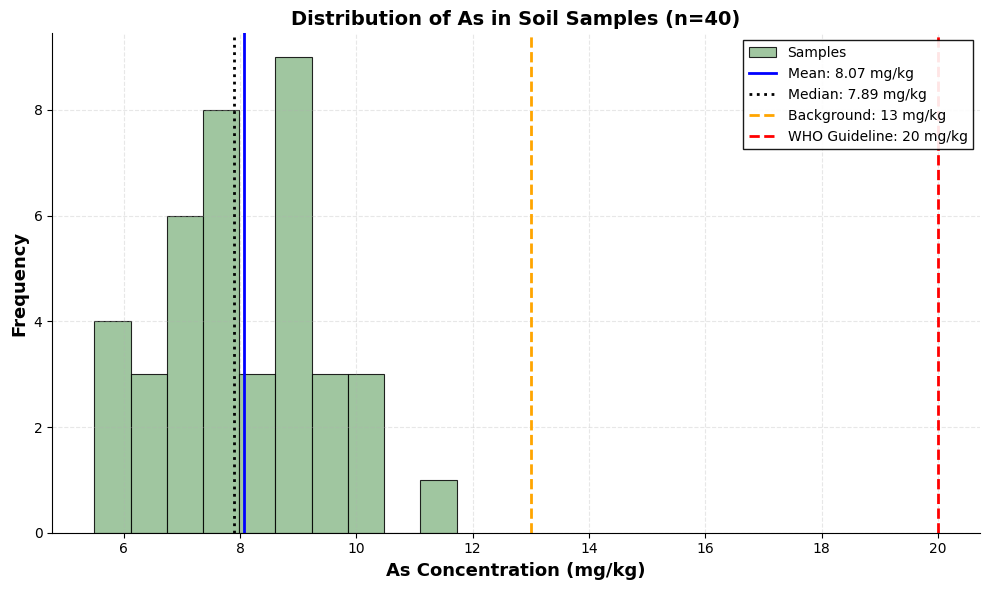

✅ Saved: distribution_As.svg


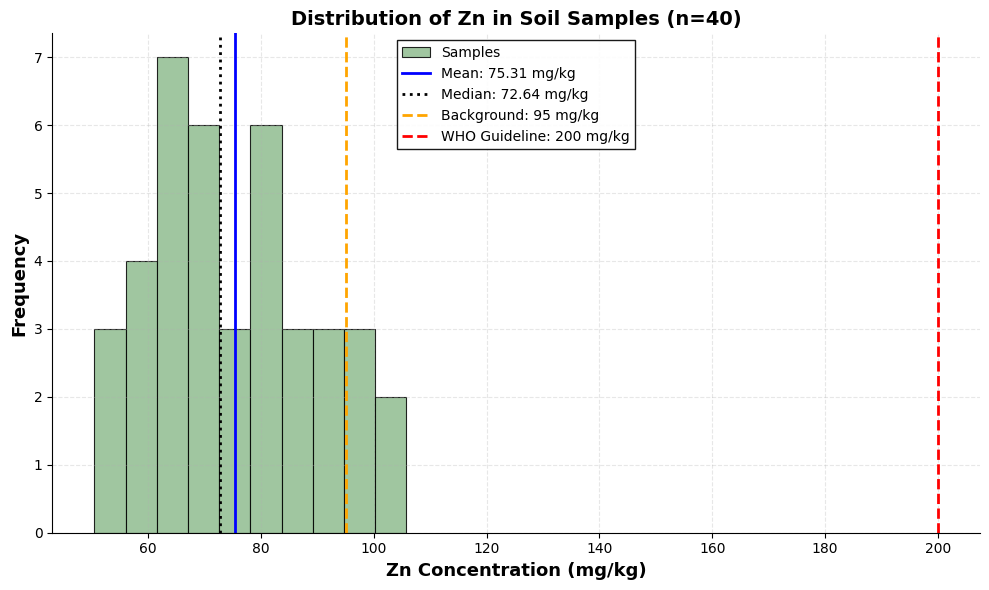

✅ Saved: distribution_Zn.svg


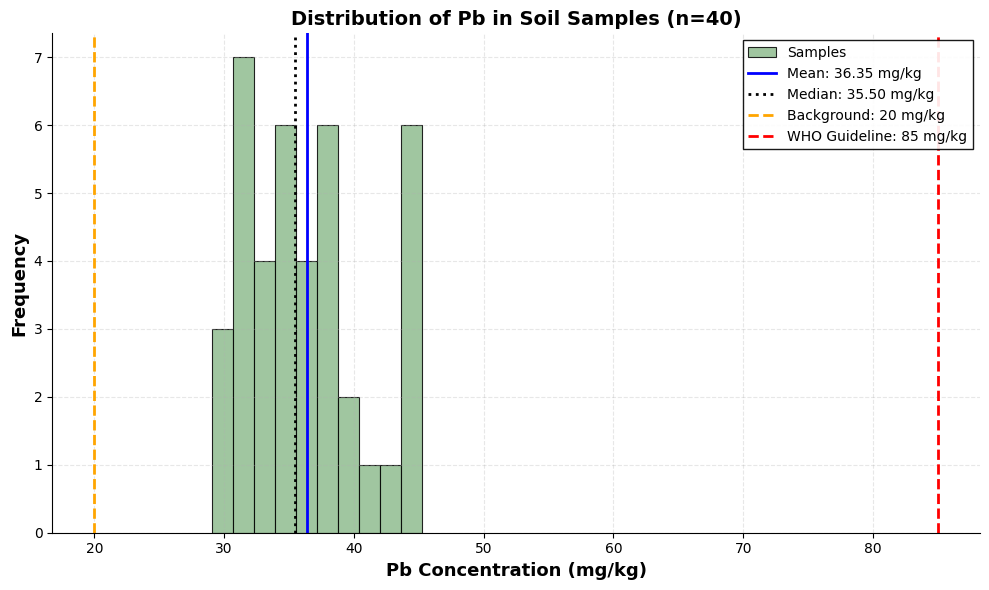

✅ Saved: distribution_Pb.svg


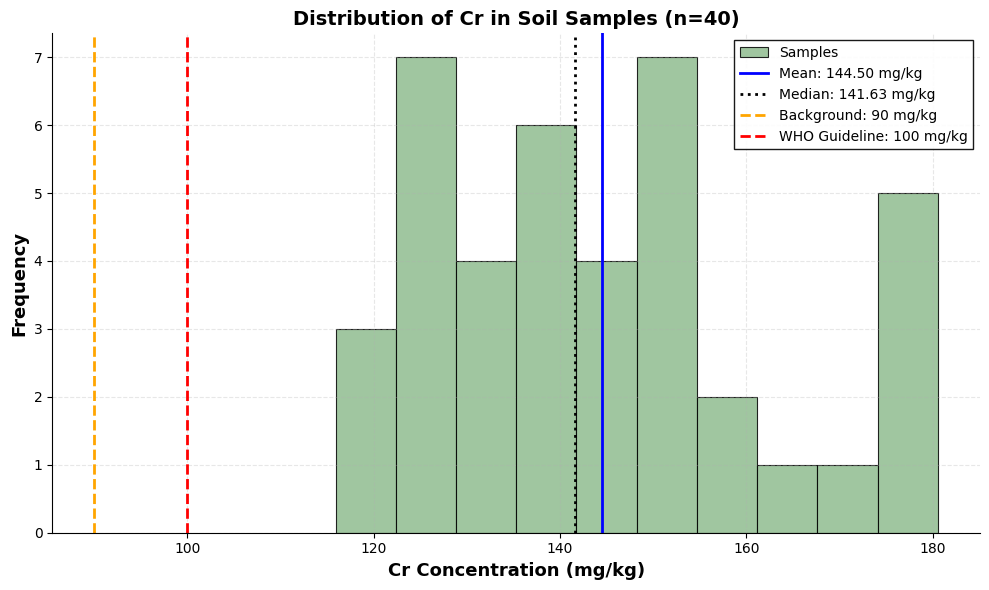

✅ Saved: distribution_Cr.svg


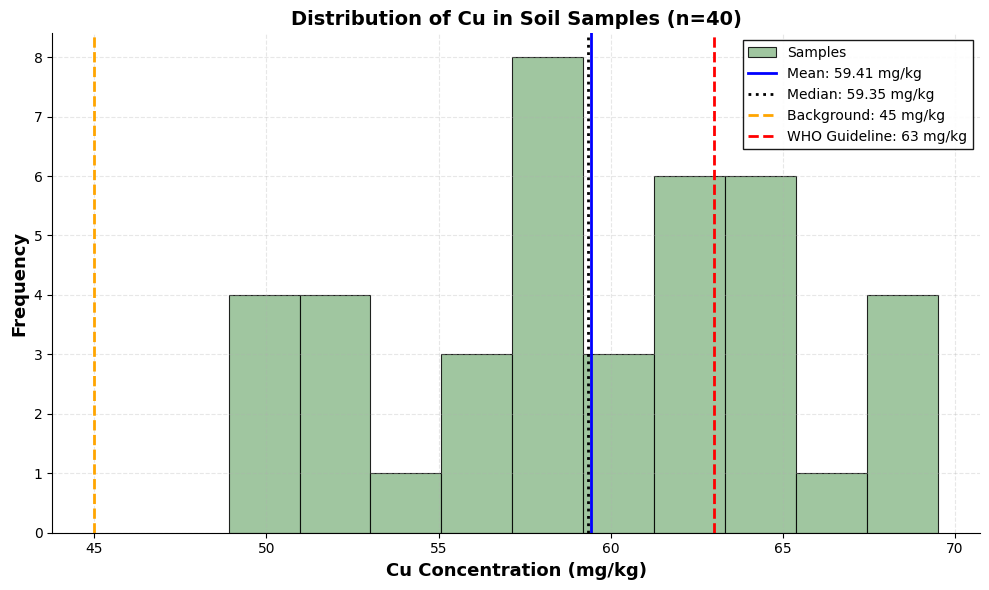

✅ Saved: distribution_Cu.svg


In [16]:
# ── CELL 6: Distribution histogram — linear scale (one per metal) ─────────────
import matplotlib.pyplot as plt

for m in metals:
    vals     = df[m].dropna().values
    mean_val = np.mean(vals)
    med_val  = np.median(vals)
    bg_val   = background[m]
    who_val  = who_guideline[m]
    n        = len(vals)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.hist(vals, bins=10, color='#8FBC8F', edgecolor='black',
            linewidth=0.8, label='Samples', alpha=0.85)

    ax.axvline(mean_val, color='blue',   linewidth=2,
               linestyle='-',  label=f'Mean: {mean_val:.2f} mg/kg')
    ax.axvline(med_val,  color='black',  linewidth=2,
               linestyle=':',  label=f'Median: {med_val:.2f} mg/kg')
    ax.axvline(bg_val,   color='orange', linewidth=2,
               linestyle='--', label=f'Background: {bg_val} mg/kg')
    ax.axvline(who_val,  color='red',    linewidth=2,
               linestyle='--', label=f'WHO Guideline: {who_val} mg/kg')

    ax.set_xlabel(f'{m} Concentration (mg/kg)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=13, fontweight='bold')
    ax.set_title(f'Distribution of {m} in Soil Samples (n={n})',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, framealpha=0.9, edgecolor='black', fancybox=False)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'distribution_{m}.svg', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: distribution_{m}.svg")

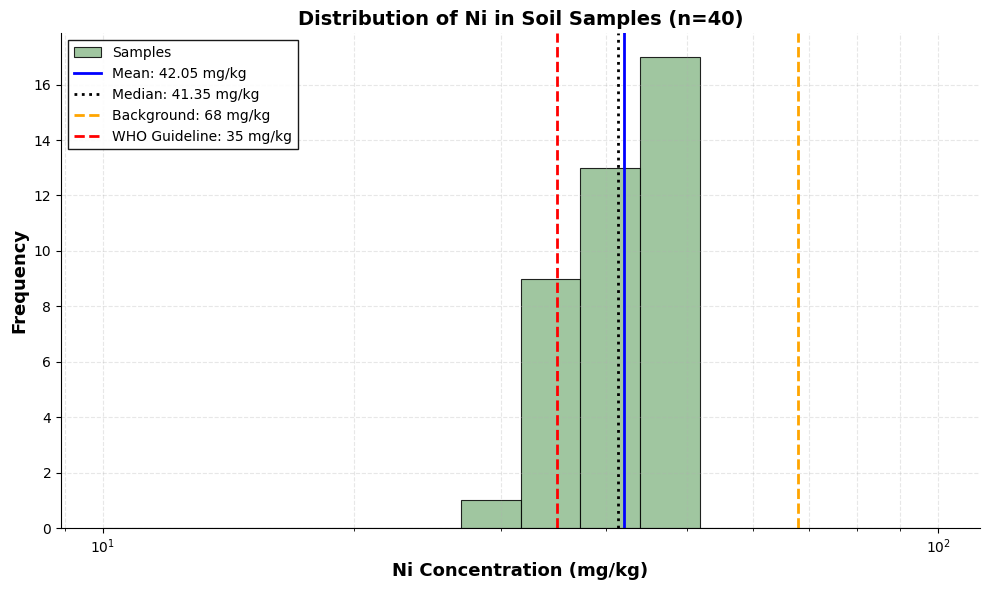

✅ Saved: distribution_log_Ni.svg


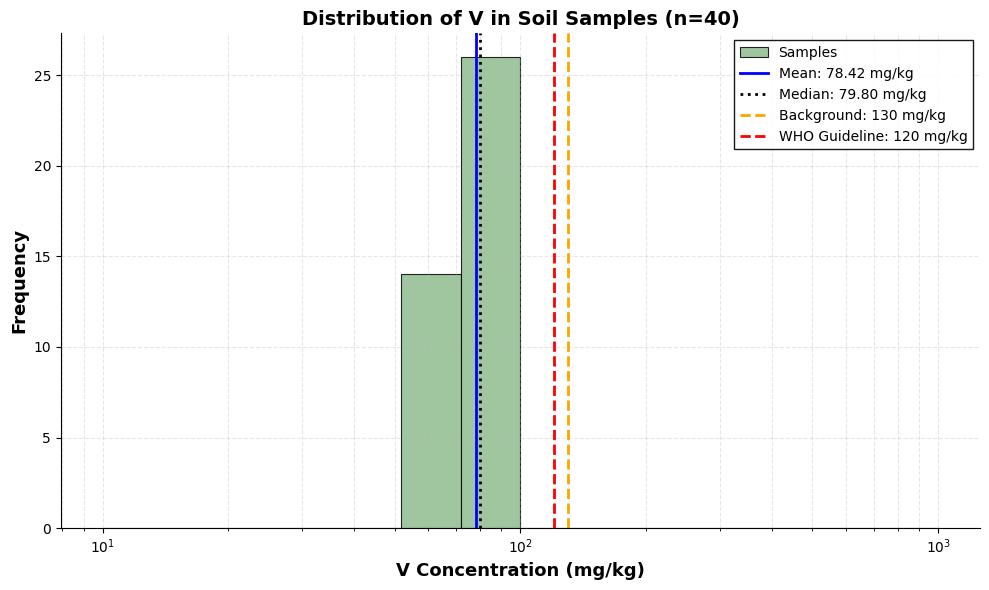

✅ Saved: distribution_log_V.svg


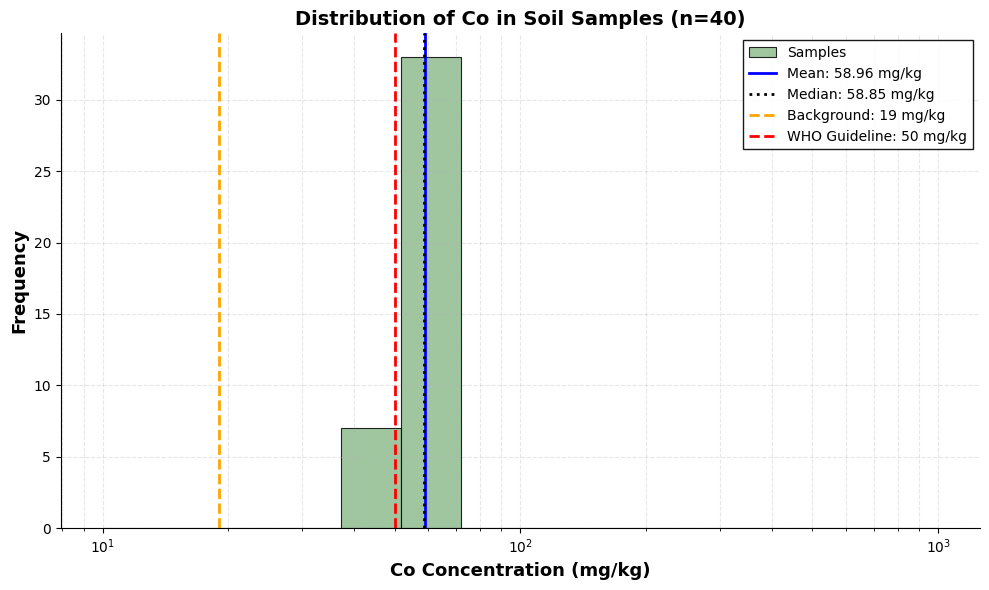

✅ Saved: distribution_log_Co.svg


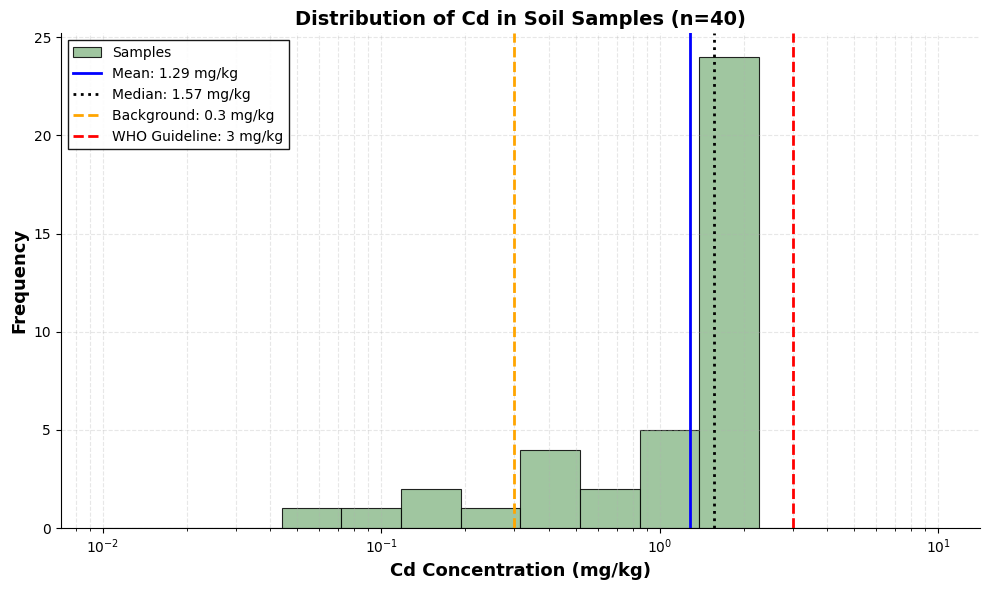

✅ Saved: distribution_log_Cd.svg


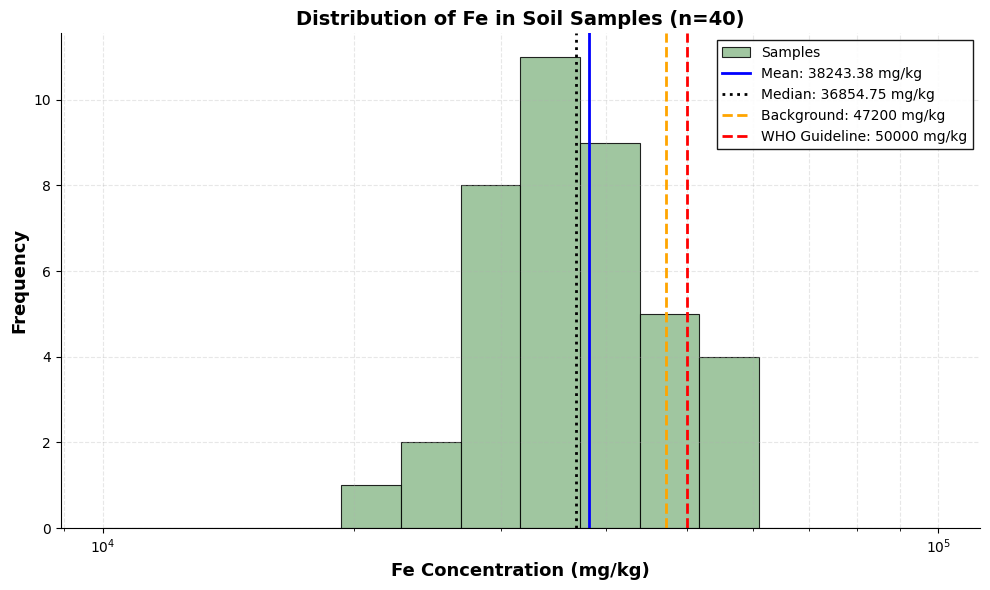

✅ Saved: distribution_log_Fe.svg


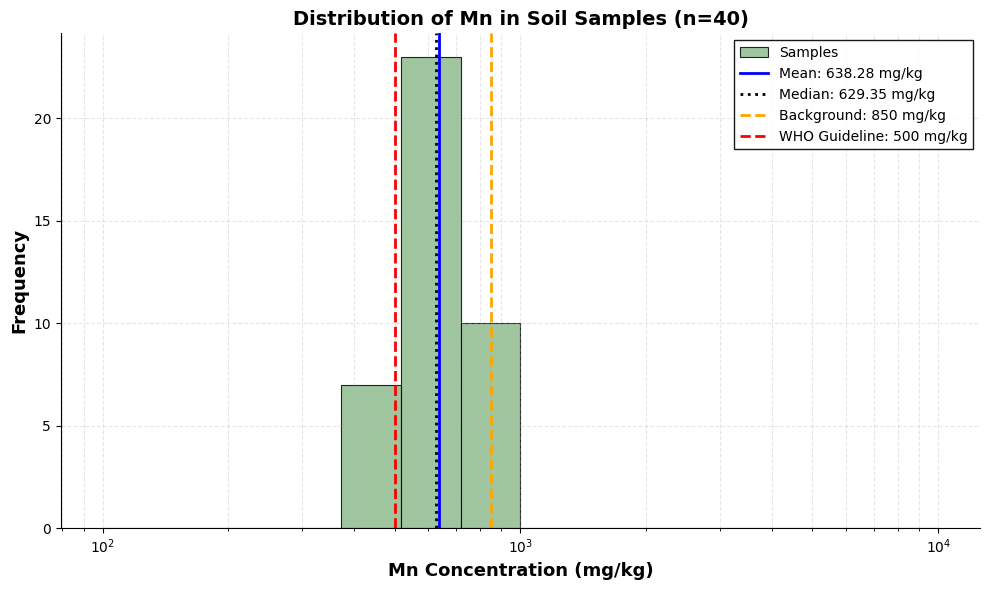

✅ Saved: distribution_log_Mn.svg


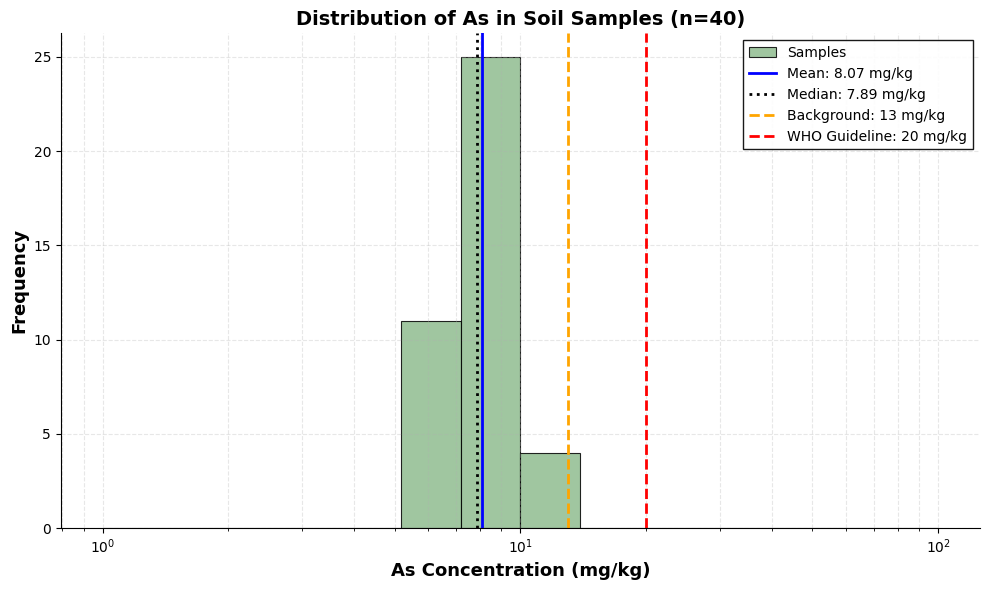

✅ Saved: distribution_log_As.svg


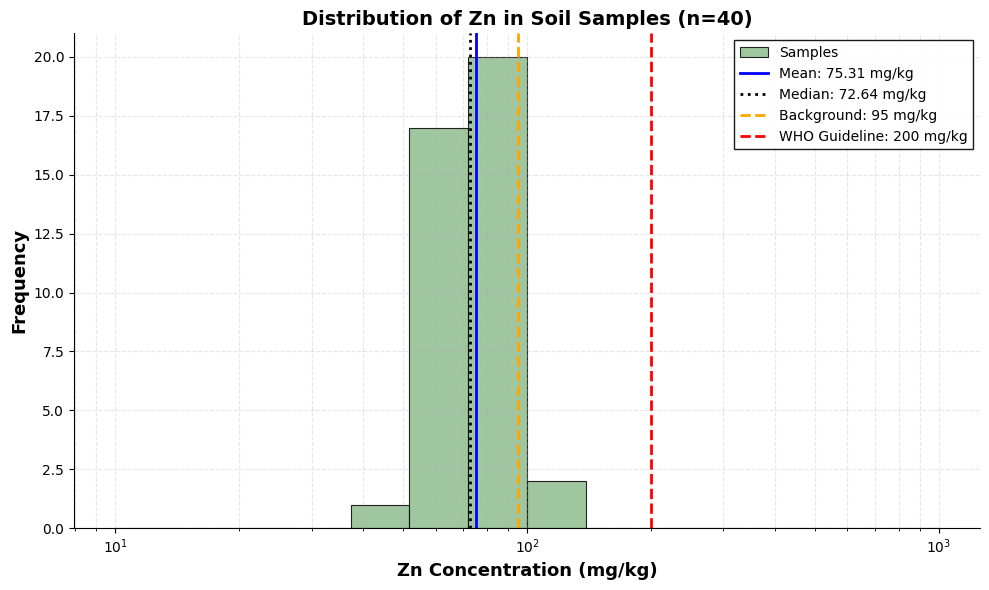

✅ Saved: distribution_log_Zn.svg


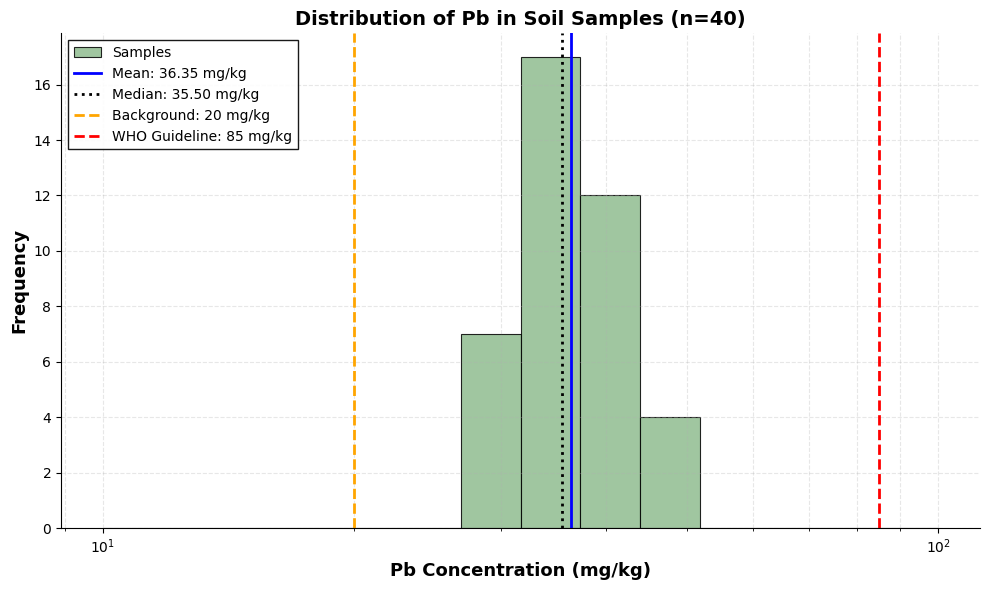

✅ Saved: distribution_log_Pb.svg


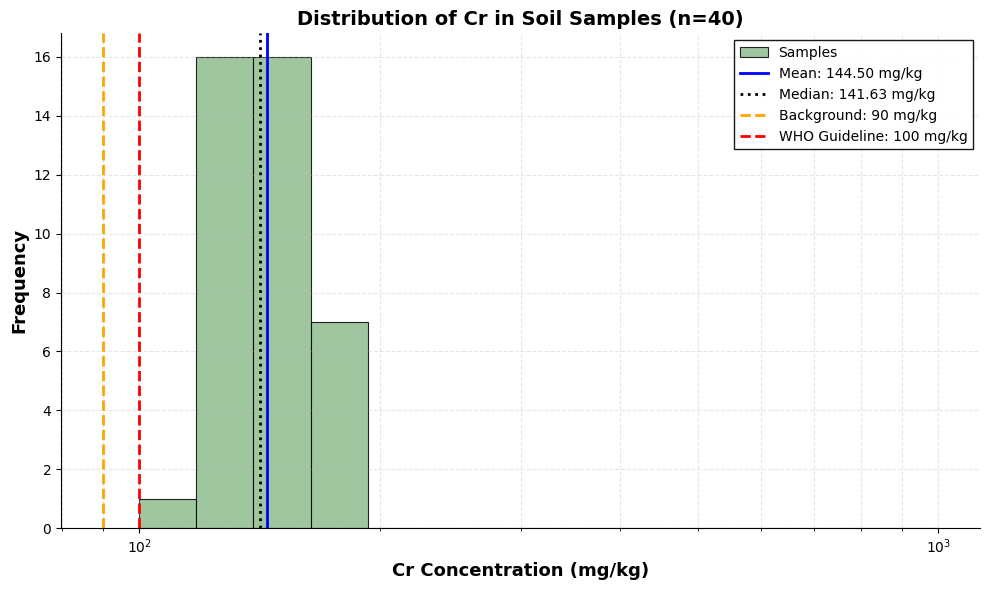

✅ Saved: distribution_log_Cr.svg


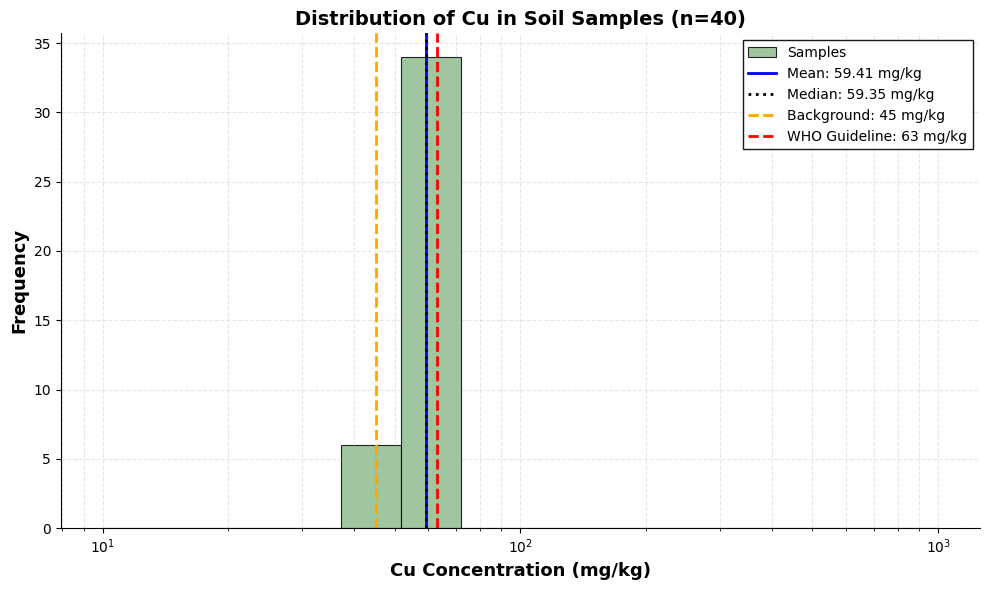

✅ Saved: distribution_log_Cu.svg


In [17]:
# ── CELL 7: Distribution histogram — log scale (Image 3 style) ───────────────
for m in metals:
    vals     = df[m].dropna().values
    mean_val = np.mean(vals)
    med_val  = np.median(vals)
    bg_val   = background[m]
    who_val  = who_guideline[m]
    n        = len(vals)

    log_min = np.floor(np.log10(vals.min()))
    log_max = np.ceil(np.log10(vals.max() * 1.5))
    bins    = np.logspace(log_min, log_max, 15)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.hist(vals, bins=bins, color='#8FBC8F', edgecolor='black',
            linewidth=0.8, label='Samples', alpha=0.85)

    ax.axvline(mean_val, color='blue',   linewidth=2,
               linestyle='-',  label=f'Mean: {mean_val:.2f} mg/kg')
    ax.axvline(med_val,  color='black',  linewidth=2,
               linestyle=':',  label=f'Median: {med_val:.2f} mg/kg')
    ax.axvline(bg_val,   color='orange', linewidth=2,
               linestyle='--', label=f'Background: {bg_val} mg/kg')
    ax.axvline(who_val,  color='red',    linewidth=2,
               linestyle='--', label=f'WHO Guideline: {who_val} mg/kg')

    ax.set_xscale('log')
    ax.set_xlabel(f'{m} Concentration (mg/kg)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=13, fontweight='bold')
    ax.set_title(f'Distribution of {m} in Soil Samples (n={n})',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, framealpha=0.9, edgecolor='black', fancybox=False)
    ax.grid(True, which='both', alpha=0.3, linestyle='--')
    ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'distribution_log_{m}.svg', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: distribution_log_{m}.svg")

/tmp/ipykernel_1430/959702472.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Zone', y=m, palette=zone_colors,


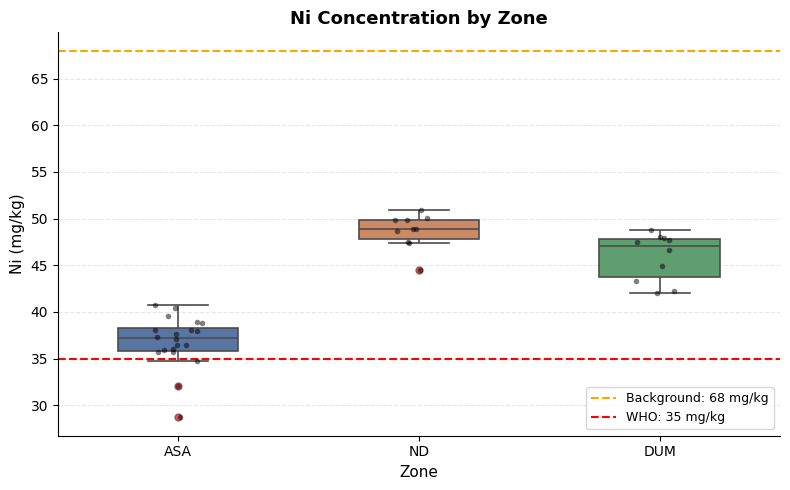

✅ Saved: boxplot_Ni.svg


/tmp/ipykernel_1430/959702472.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Zone', y=m, palette=zone_colors,


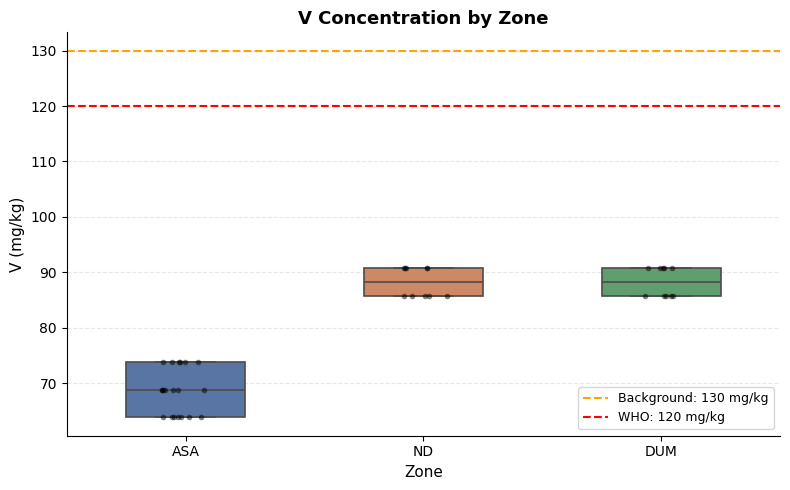

✅ Saved: boxplot_V.svg


/tmp/ipykernel_1430/959702472.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Zone', y=m, palette=zone_colors,


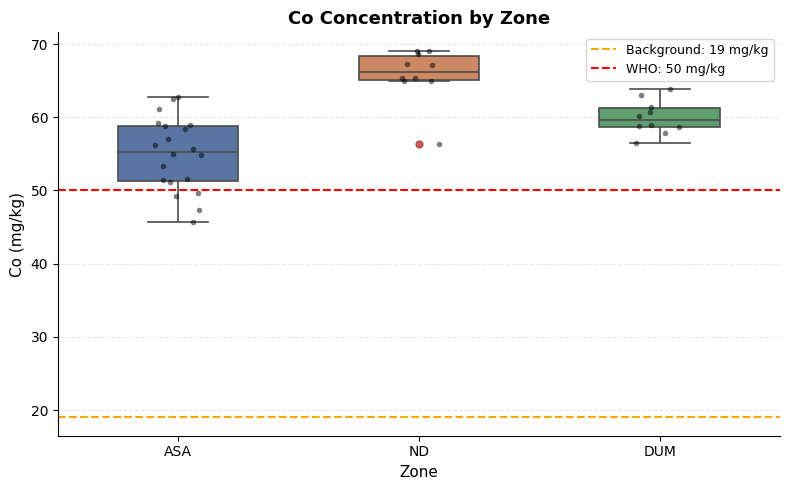

✅ Saved: boxplot_Co.svg


/tmp/ipykernel_1430/959702472.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Zone', y=m, palette=zone_colors,


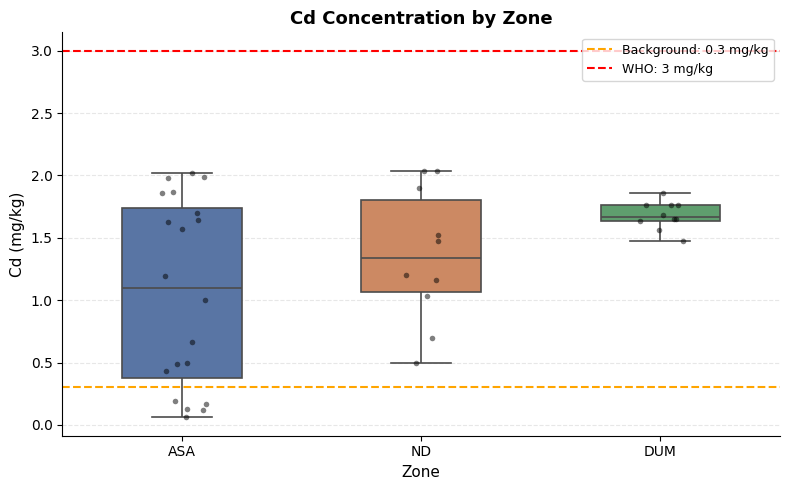

✅ Saved: boxplot_Cd.svg


/tmp/ipykernel_1430/959702472.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Zone', y=m, palette=zone_colors,


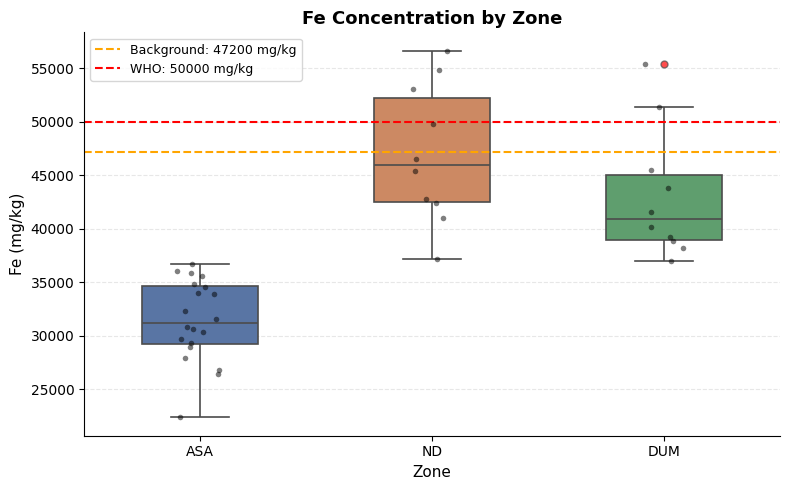

✅ Saved: boxplot_Fe.svg


/tmp/ipykernel_1430/959702472.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Zone', y=m, palette=zone_colors,


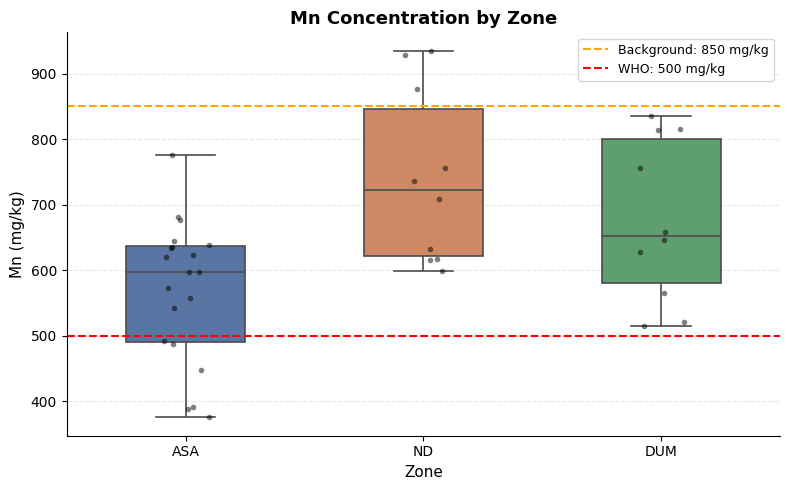

✅ Saved: boxplot_Mn.svg


/tmp/ipykernel_1430/959702472.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Zone', y=m, palette=zone_colors,


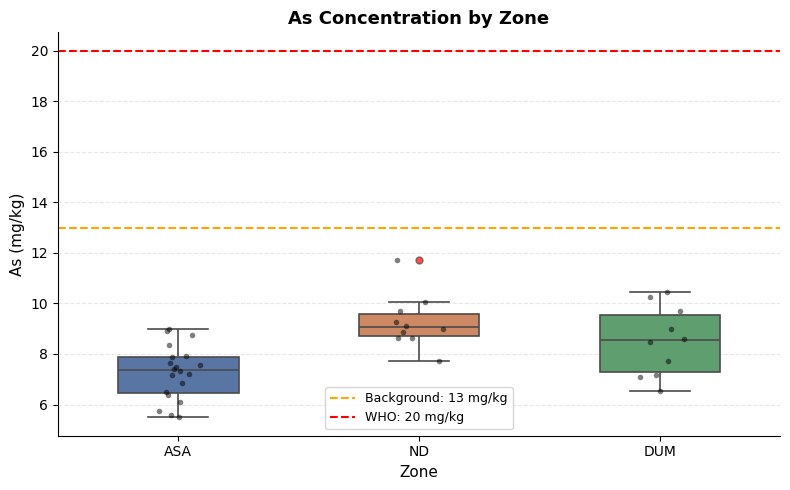

✅ Saved: boxplot_As.svg


/tmp/ipykernel_1430/959702472.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Zone', y=m, palette=zone_colors,


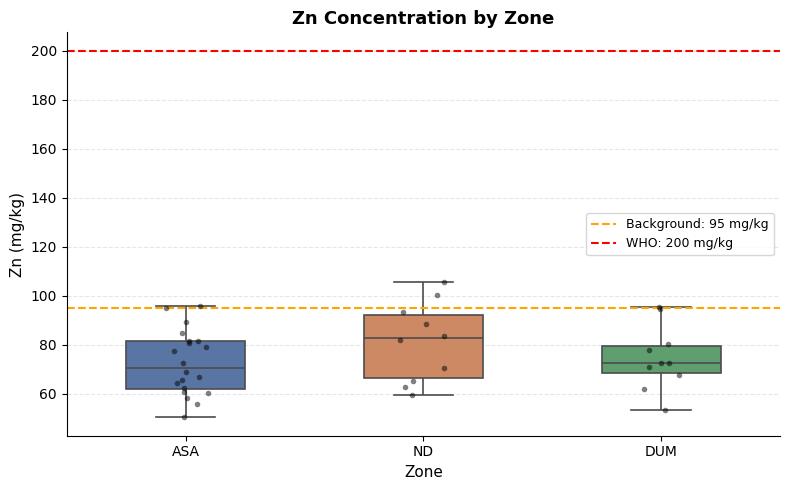

✅ Saved: boxplot_Zn.svg


/tmp/ipykernel_1430/959702472.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Zone', y=m, palette=zone_colors,


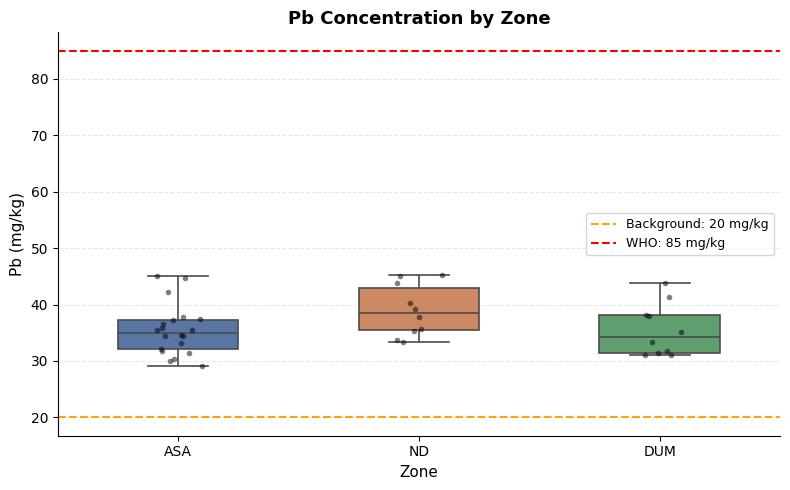

✅ Saved: boxplot_Pb.svg


/tmp/ipykernel_1430/959702472.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Zone', y=m, palette=zone_colors,


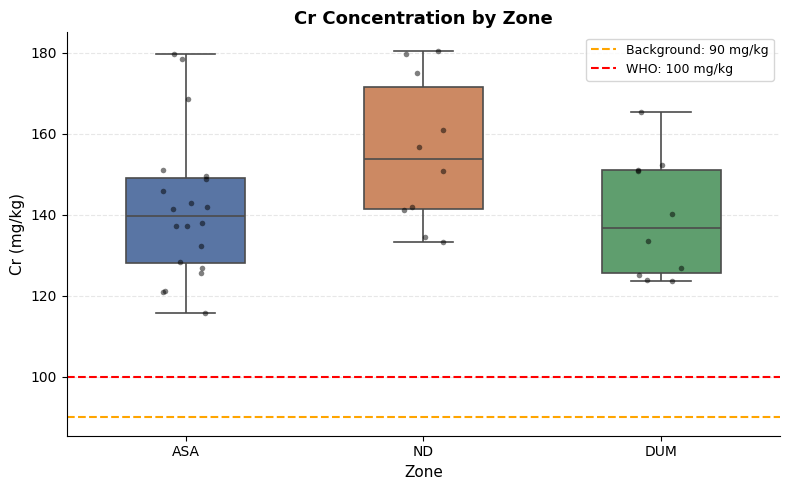

✅ Saved: boxplot_Cr.svg


/tmp/ipykernel_1430/959702472.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Zone', y=m, palette=zone_colors,


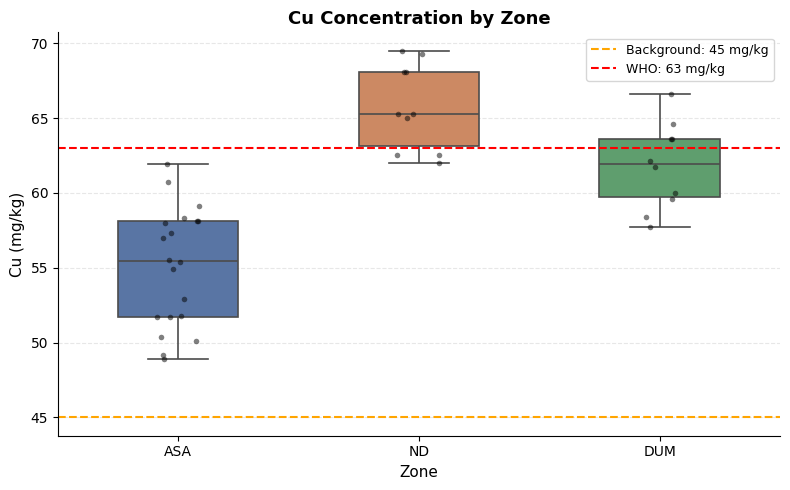

✅ Saved: boxplot_Cu.svg


In [18]:
# ── CELL 8: Boxplot by zone per metal ────────────────────────────────────────
import seaborn as sns

zone_colors = {'ASA': '#4C72B0', 'ND': '#DD8452', 'DUM': '#55A868'}

for m in metals:
    fig, ax = plt.subplots(figsize=(8, 5))

    sns.boxplot(data=df, x='Zone', y=m, palette=zone_colors,
                width=0.5, linewidth=1.2,
                flierprops=dict(marker='o', markerfacecolor='red',
                                markersize=5, alpha=0.7), ax=ax)
    sns.stripplot(data=df, x='Zone', y=m, color='black',
                  size=4, alpha=0.5, jitter=True, ax=ax)

    ax.axhline(background[m],   color='orange', linewidth=1.5,
               linestyle='--', label=f'Background: {background[m]} mg/kg')
    ax.axhline(who_guideline[m], color='red',   linewidth=1.5,
               linestyle='--', label=f'WHO: {who_guideline[m]} mg/kg')

    ax.set_title(f'{m} Concentration by Zone', fontsize=13, fontweight='bold')
    ax.set_xlabel('Zone', fontsize=11)
    ax.set_ylabel(f'{m} (mg/kg)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'boxplot_{m}.svg', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: boxplot_{m}.svg")

In [19]:
# ── CELL 9: Contamination Factor (CF) ────────────────────────────────────────
# CF = C_metal / C_background
# <1: Low | 1–3: Moderate | 3–6: Considerable | ≥6: Very High

def cf_class(v):
    if v < 1:    return 'Low'
    elif v < 3:  return 'Moderate'
    elif v < 6:  return 'Considerable'
    else:        return 'Very High'

cf_df = df[['Sample','Zone']].copy()
for m in metals:
    cf_df[f'CF_{m}'] = (df[m] / background[m]).round(3)
    cf_df[f'CF_{m}_class'] = cf_df[f'CF_{m}'].apply(cf_class)

print("✅ Contamination Factor (CF):")
for m in metals:
    mean_cf = cf_df[f'CF_{m}'].mean()
    print(f"   {m:4s}: Mean CF = {mean_cf:.3f} → {cf_class(mean_cf)}")

cf_df.to_excel('contamination_factor.xlsx', index=False)
print("\n✅ Saved: contamination_factor.xlsx")

✅ Contamination Factor (CF):
   Ni  : Mean CF = 0.618 → Low
   V   : Mean CF = 0.603 → Low
   Co  : Mean CF = 3.103 → Considerable
   Cd  : Mean CF = 4.296 → Considerable
   Fe  : Mean CF = 0.810 → Low
   Mn  : Mean CF = 0.751 → Low
   As  : Mean CF = 0.621 → Low
   Zn  : Mean CF = 0.793 → Low
   Pb  : Mean CF = 1.818 → Moderate
   Cr  : Mean CF = 1.606 → Moderate
   Cu  : Mean CF = 1.320 → Moderate

✅ Saved: contamination_factor.xlsx


In [20]:
# ── CELL 10: Geo-accumulation Index (Igeo) ────────────────────────────────────
# Igeo = log2(Cn / 1.5 × Bn)
# ≤0: Uncontaminated | 0–1: Uncontaminated–Moderate | 1–2: Moderate
# 2–3: Moderate–Heavy | 3–4: Heavy | 4–5: Heavy–Extreme | ≥5: Extreme

def igeo_class(v):
    if v <= 0:   return 'Practically Uncontaminated'
    elif v <= 1: return 'Uncontaminated to Moderate'
    elif v <= 2: return 'Moderately Contaminated'
    elif v <= 3: return 'Moderate to Heavy'
    elif v <= 4: return 'Heavily Contaminated'
    elif v <= 5: return 'Heavy to Extreme'
    else:        return 'Extremely Contaminated'

igeo_df = df[['Sample','Zone']].copy()
for m in metals:
    igeo_df[f'Igeo_{m}'] = np.log2(df[m] / (1.5 * background[m])).round(3)
    igeo_df[f'Igeo_{m}_class'] = igeo_df[f'Igeo_{m}'].apply(igeo_class)

print("✅ Geo-accumulation Index (Igeo):")
for m in metals:
    mean_igeo = igeo_df[f'Igeo_{m}'].mean()
    print(f"   {m:4s}: Mean Igeo = {mean_igeo:.3f} → {igeo_class(mean_igeo)}")

igeo_df.to_excel('geoaccumulation_index.xlsx', index=False)
print("\n✅ Saved: geoaccumulation_index.xlsx")

✅ Geo-accumulation Index (Igeo):
   Ni  : Mean Igeo = -1.293 → Practically Uncontaminated
   V   : Mean Igeo = -1.327 → Practically Uncontaminated
   Co  : Mean Igeo = 1.041 → Moderately Contaminated
   Cd  : Mean Igeo = 1.142 → Moderately Contaminated
   Fe  : Mean Igeo = -0.924 → Practically Uncontaminated
   Mn  : Mean Igeo = -1.032 → Practically Uncontaminated
   As  : Mean Igeo = -1.294 → Practically Uncontaminated
   Zn  : Mean Igeo = -0.945 → Practically Uncontaminated
   Pb  : Mean Igeo = 0.266 → Uncontaminated to Moderate
   Cr  : Mean Igeo = 0.087 → Uncontaminated to Moderate
   Cu  : Mean Igeo = -0.191 → Practically Uncontaminated

✅ Saved: geoaccumulation_index.xlsx


In [21]:
# ── CELL 11: Enrichment Factor (EF) ──────────────────────────────────────────
# EF = (Cmetal/CFe)sample / (Cmetal/CFe)background
# Fe used as reference element
# <2: Minimal | 2–5: Moderate | 5–20: Significant | 20–40: Very High | >40: Extreme

def ef_class(v):
    if v < 2:    return 'Minimal'
    elif v < 5:  return 'Moderate'
    elif v < 20: return 'Significant'
    elif v < 40: return 'Very High'
    else:        return 'Extremely High'

ef_metals = [m for m in metals if m != 'Fe']
ef_df = df[['Sample','Zone']].copy()

for m in ef_metals:
    ef_df[f'EF_{m}'] = (
        (df[m] / df['Fe']) / (background[m] / background['Fe'])
    ).round(3)
    ef_df[f'EF_{m}_class'] = ef_df[f'EF_{m}'].apply(ef_class)

print("✅ Enrichment Factor (EF) — Fe as reference:")
for m in ef_metals:
    mean_ef = ef_df[f'EF_{m}'].mean()
    print(f"   {m:4s}: Mean EF = {mean_ef:.3f} → {ef_class(mean_ef)}")

ef_df.to_excel('enrichment_factor.xlsx', index=False)
print("\n✅ Saved: enrichment_factor.xlsx")

✅ Enrichment Factor (EF) — Fe as reference:
   Ni  : Mean EF = 0.779 → Minimal
   V   : Mean EF = 0.765 → Minimal
   Co  : Mean EF = 3.946 → Moderate
   Cd  : Mean EF = 5.365 → Significant
   Mn  : Mean EF = 0.938 → Minimal
   As  : Mean EF = 0.782 → Minimal
   Zn  : Mean EF = 1.005 → Minimal
   Pb  : Mean EF = 2.343 → Moderate
   Cr  : Mean EF = 2.070 → Moderate
   Cu  : Mean EF = 1.682 → Minimal

✅ Saved: enrichment_factor.xlsx


In [22]:
# ── CELL 12: Pollution Load Index (PLI) ───────────────────────────────────────
# PLI = (CF1 × CF2 × ... × CFn) ^ (1/n)
# <1: No pollution | ≥1: Polluted

pli_df = df[['Sample','Zone']].copy()
cf_vals = pd.DataFrame({m: df[m] / background[m] for m in metals})
pli_df['PLI'] = (cf_vals.prod(axis=1) ** (1/len(metals))).round(3)
pli_df['PLI_class'] = pli_df['PLI'].apply(
    lambda x: 'No Pollution' if x < 1 else 'Polluted'
)

print("✅ Pollution Load Index (PLI):")
print(f"   Mean : {pli_df['PLI'].mean():.3f}")
print(f"   Min  : {pli_df['PLI'].min():.3f}")
print(f"   Max  : {pli_df['PLI'].max():.3f}")
print(f"   Polluted samples: {(pli_df['PLI'] >= 1).sum()} / {len(pli_df)}")

pli_df.to_excel('pollution_load_index.xlsx', index=False)
print("\n✅ Saved: pollution_load_index.xlsx")

✅ Pollution Load Index (PLI):
   Mean : 1.144
   Min  : 0.752
   Max  : 1.395
   Polluted samples: 32 / 40

✅ Saved: pollution_load_index.xlsx


In [23]:
# ── CELL 13: Health risk parameters (Table 3.2 & 3.3) ────────────────────────
params = {
    'EF'    : {'Adults': 365,   'Children': 365},
    'ED'    : {'Adults': 24,    'Children': 6},
    'BW'    : {'Adults': 70,    'Children': 20},
    'AT'    : {'Adults': 8760,  'Children': 2190},
    'AT_c'  : {'Adults': 25550, 'Children': 25550},
    'IR_ing': {'Adults': 100,   'Children': 200},
    'IR_inh': {'Adults': 12.8,  'Children': 7.63},
    'PEF'   : 1.36e9,
    'ESA'   : {'Adults': 4350,  'Children': 1600},
    'SAF'   : {'Adults': 0.7,   'Children': 0.2},
    'DAF'   : {'Adults': 0.001, 'Children': 0.001},
}

RfD = {
    'Ni': {'Ingestion': 0.02,   'Inhalation': 0.0002,  'Dermal': 0.0054},
    'V' : {'Ingestion': 0.001,  'Inhalation': 0.0001,  'Dermal': 0.00009},
    'Co': {'Ingestion': 0.03,   'Inhalation': 5.00e-5, 'Dermal': 8.1e-5},
    'Cd': {'Ingestion': 0.0005, 'Inhalation': 1.00e-5, 'Dermal': 2.5e-5},
    'Fe': {'Ingestion': 0.7,    'Inhalation': 0.7,     'Dermal': 0.07},
    'Mn': {'Ingestion': 0.024,  'Inhalation': 0.05,    'Dermal': 0.0056},
    'As': {'Ingestion': 0.0003, 'Inhalation': 0.00003, 'Dermal': 0.00012},
    'Zn': {'Ingestion': 0.3,    'Inhalation': 0.01,    'Dermal': 0.06},
    'Pb': {'Ingestion': 0.0014, 'Inhalation': 0.0001,  'Dermal': None},
    'Cr': {'Ingestion': 0.003,  'Inhalation': 0.0001,  'Dermal': 0.0003},
    'Cu': {'Ingestion': 0.04,   'Inhalation': 0.01,    'Dermal': 0.02},
}

CSF = {
    'Ni': {'Ingestion': 0.91,   'Inhalation': 0.91,  'Dermal': 4.55},
    'As': {'Ingestion': 1.5,    'Inhalation': 12.0,  'Dermal': 47.5},
    'Pb': {'Ingestion': 0.0085, 'Inhalation': 0.042, 'Dermal': 0.425},
    'Cr': {'Ingestion': 0.42,   'Inhalation': 510.0, 'Dermal': 2.1},
}

print("✅ Health risk parameters loaded")
print(f"   Carcinogenic metals: {list(CSF.keys())}")

✅ Health risk parameters loaded
   Carcinogenic metals: ['Ni', 'As', 'Pb', 'Cr']


In [24]:
# ── CELL 14: Average Daily Dose (ADD) ─────────────────────────────────────────
add_rows = []

for _, row in df.iterrows():
    for pop in ['Adults', 'Children']:
        rec = {'Sample': row['Sample'], 'Zone': row['Zone'], 'Population': pop}
        for m in metals:
            C = row[m]
            EF = params['EF'][pop];  ED = params['ED'][pop]
            BW = params['BW'][pop];  AT = params['AT'][pop]

            rec[f'{m}_ADD_ing'] = (C * params['IR_ing'][pop] * EF * ED) / (BW * AT)
            rec[f'{m}_ADD_inh'] = (C * params['IR_inh'][pop] * EF * ED) / (params['PEF'] * BW * AT)
            rec[f'{m}_ADD_der'] = (C * params['ESA'][pop] * params['SAF'][pop] *
                                   params['DAF'][pop] * EF * ED) / (BW * AT)
        add_rows.append(rec)

add_df = pd.DataFrame(add_rows)
add_df.to_excel('exposure_doses_ADD.xlsx', index=False)
print(f"✅ ADD computed — {len(add_df)} rows")
print("✅ Saved: exposure_doses_ADD.xlsx")

✅ ADD computed — 80 rows
✅ Saved: exposure_doses_ADD.xlsx


In [25]:
# ── CELL 15: Non-carcinogenic risk — HQ and HI ───────────────────────────────
# HQ = ADD / RfD
# HI = ΣHQ (all metals, all pathways)
# HQ or HI > 1 = potential risk

hq_rows = []

for _, row in add_df.iterrows():
    rec = {'Sample': row['Sample'], 'Zone': row['Zone'],
           'Population': row['Population']}
    hi = 0
    for m in metals:
        HQ_ing = row[f'{m}_ADD_ing'] / RfD[m]['Ingestion']
        HQ_inh = row[f'{m}_ADD_inh'] / RfD[m]['Inhalation']
        HQ_der = (row[f'{m}_ADD_der'] / RfD[m]['Dermal']
                  if RfD[m]['Dermal'] is not None else 0)
        HQ_tot = HQ_ing + HQ_inh + HQ_der
        hi    += HQ_tot
        rec[f'{m}_HQ_ing']   = round(HQ_ing, 6)
        rec[f'{m}_HQ_inh']   = round(HQ_inh, 8)
        rec[f'{m}_HQ_der']   = round(HQ_der, 6)
        rec[f'{m}_HQ_total'] = round(HQ_tot, 6)
    rec['HI'] = round(hi, 4)
    hq_rows.append(rec)

hq_df = pd.DataFrame(hq_rows)

print("✅ HQ and HI computed")
for pop in ['Adults','Children']:
    sub = hq_df[hq_df['Population'] == pop]
    print(f"\n  {pop}:")
    print(f"    Mean HI : {sub['HI'].mean():.4f}")
    print(f"    Max HI  : {sub['HI'].max():.4f}")
    print(f"    HI > 1  : {(sub['HI'] > 1).sum()} / {len(sub)} samples")

hq_df.to_excel('hazard_quotient_HQ_HI.xlsx', index=False)
print("\n✅ Saved: hazard_quotient_HQ_HI.xlsx")

✅ HQ and HI computed

  Adults:
    Mean HI : 509324.8815
    Max HI  : 613368.7715
    HI > 1  : 40 / 40 samples

  Children:
    Mean HI : 2736685.8229
    Max HI  : 3315982.2380
    HI > 1  : 40 / 40 samples

✅ Saved: hazard_quotient_HQ_HI.xlsx


In [26]:
# ── CELL 16: Carcinogenic Risk (CR) ───────────────────────────────────────────
# CR = LADD × CSF
# <1e-6: Acceptable | 1e-6 to 1e-4: Tolerable | >1e-4: Unacceptable

def cr_level(v):
    if v < 1e-6:   return 'Acceptable'
    elif v < 1e-4: return 'Tolerable'
    else:          return 'Unacceptable'

cr_rows = []
carc_metals = list(CSF.keys())

for _, row in df.iterrows():
    for pop in ['Adults','Children']:
        rec = {'Sample': row['Sample'], 'Zone': row['Zone'],
               'Population': pop}
        total_cr = 0
        for m in carc_metals:
            C  = row[m]
            EF = params['EF'][pop];  ED = params['ED'][pop]
            BW = params['BW'][pop];  AT = params['AT_c'][pop]

            LADD_ing = (C * params['IR_ing'][pop] * EF * ED) / (BW * AT)
            LADD_inh = (C * params['IR_inh'][pop] * EF * ED) / (params['PEF'] * BW * AT)
            LADD_der = (C * params['ESA'][pop] * params['SAF'][pop] *
                        params['DAF'][pop] * EF * ED) / (BW * AT)

            CR_ing = LADD_ing * CSF[m]['Ingestion']
            CR_inh = LADD_inh * CSF[m]['Inhalation']
            CR_der = LADD_der * CSF[m]['Dermal']
            CR_tot = CR_ing + CR_inh + CR_der
            total_cr += CR_tot

            rec[f'{m}_CR_ing']   = CR_ing
            rec[f'{m}_CR_inh']   = CR_inh
            rec[f'{m}_CR_der']   = CR_der
            rec[f'{m}_CR_total'] = CR_tot

        rec['Total_CR']  = total_cr
        rec['CR_level']  = cr_level(total_cr)
        cr_rows.append(rec)

cr_df = pd.DataFrame(cr_rows)

print("✅ Carcinogenic Risk (CR) computed")
for pop in ['Adults','Children']:
    sub = cr_df[cr_df['Population'] == pop]
    print(f"\n  {pop}:")
    print(f"    Mean CR      : {sub['Total_CR'].mean():.2e}")
    print(f"    Max CR       : {sub['Total_CR'].max():.2e}")
    print(f"    Unacceptable : {(sub['Total_CR'] > 1e-4).sum()} samples")
    print(f"    Tolerable    : {((sub['Total_CR'] >= 1e-6) & (sub['Total_CR'] <= 1e-4)).sum()} samples")
    print(f"    Acceptable   : {(sub['Total_CR'] < 1e-6).sum()} samples")

cr_df.to_excel('carcinogenic_risk_CR.xlsx', index=False)
print("\n✅ Saved: carcinogenic_risk_CR.xlsx")

✅ Carcinogenic Risk (CR) computed

  Adults:
    Mean CR      : 6.79e+01
    Max CR       : 8.24e+01
    Unacceptable : 40 samples
    Tolerable    : 0 samples
    Acceptable   : 0 samples

  Children:
    Mean CR      : 9.67e+01
    Max CR       : 1.18e+02
    Unacceptable : 40 samples
    Tolerable    : 0 samples
    Acceptable   : 0 samples

✅ Saved: carcinogenic_risk_CR.xlsx


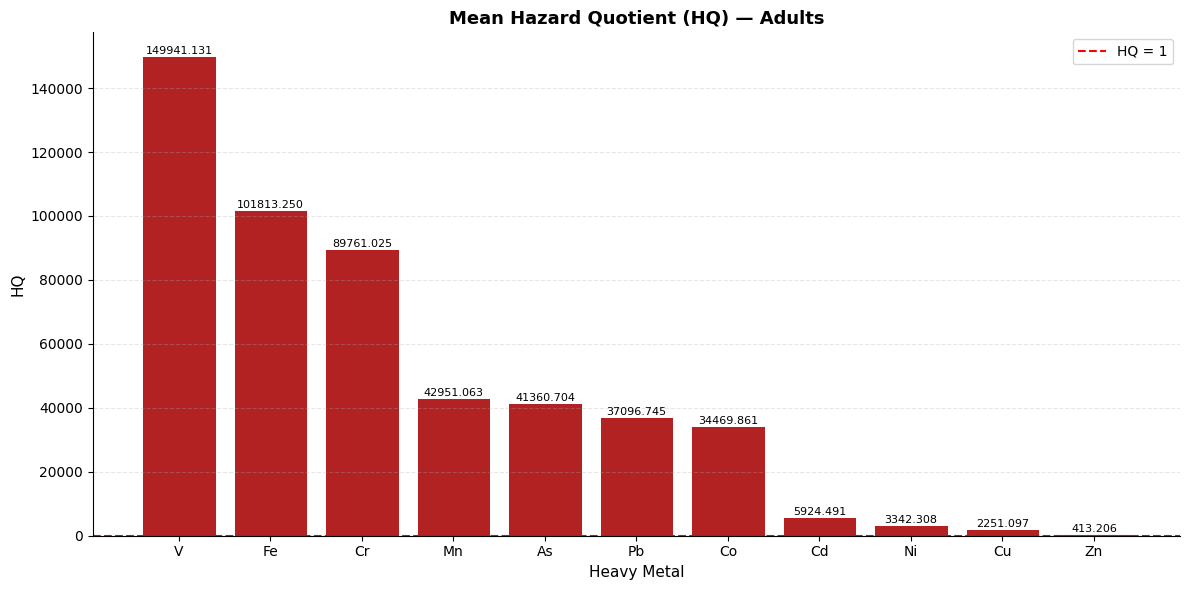

✅ Saved: HQ_bar_Adults.svg


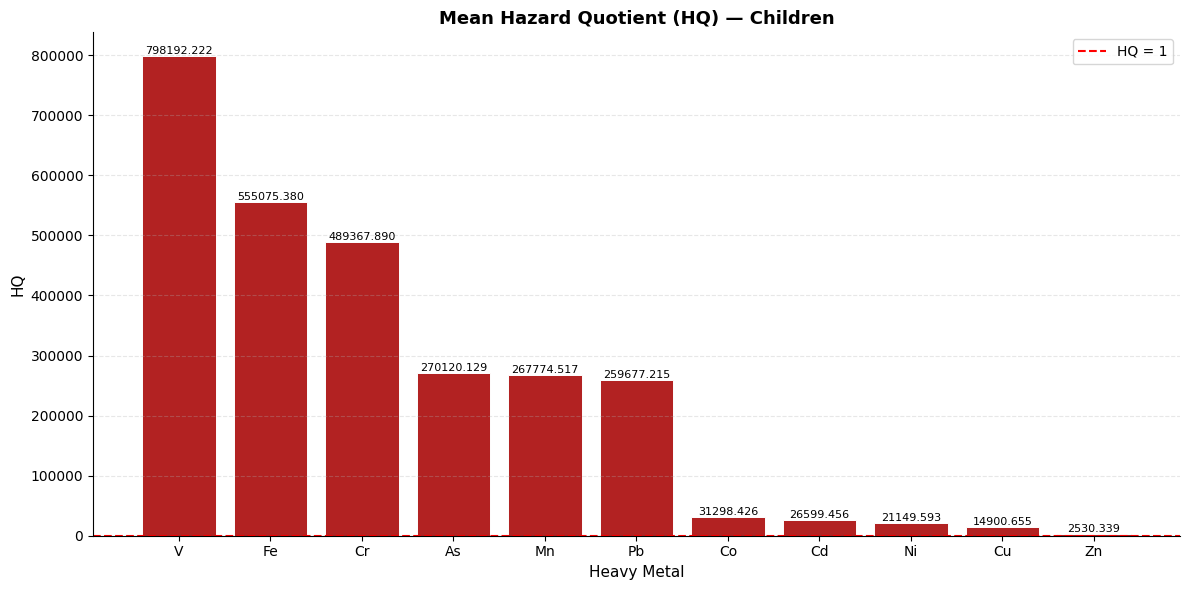

✅ Saved: HQ_bar_Children.svg


In [27]:
# ── CELL 17: HQ bar chart per metal per population ───────────────────────────
import matplotlib.pyplot as plt

for pop in ['Adults','Children']:
    sub = hq_df[hq_df['Population'] == pop]
    mean_hq = {m: sub[f'{m}_HQ_total'].mean() for m in metals}
    sorted_m = sorted(mean_hq, key=mean_hq.get, reverse=True)
    colors   = ['firebrick' if mean_hq[m] > 1 else 'steelblue' for m in sorted_m]

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(sorted_m, [mean_hq[m] for m in sorted_m],
                  color=colors, edgecolor='white', linewidth=0.7)
    ax.axhline(1, color='red', linewidth=1.5, linestyle='--', label='HQ = 1')

    for bar, m in zip(bars, sorted_m):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{mean_hq[m]:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_title(f'Mean Hazard Quotient (HQ) — {pop}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Heavy Metal', fontsize=11)
    ax.set_ylabel('HQ', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'HQ_bar_{pop}.svg', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: HQ_bar_{pop}.svg")

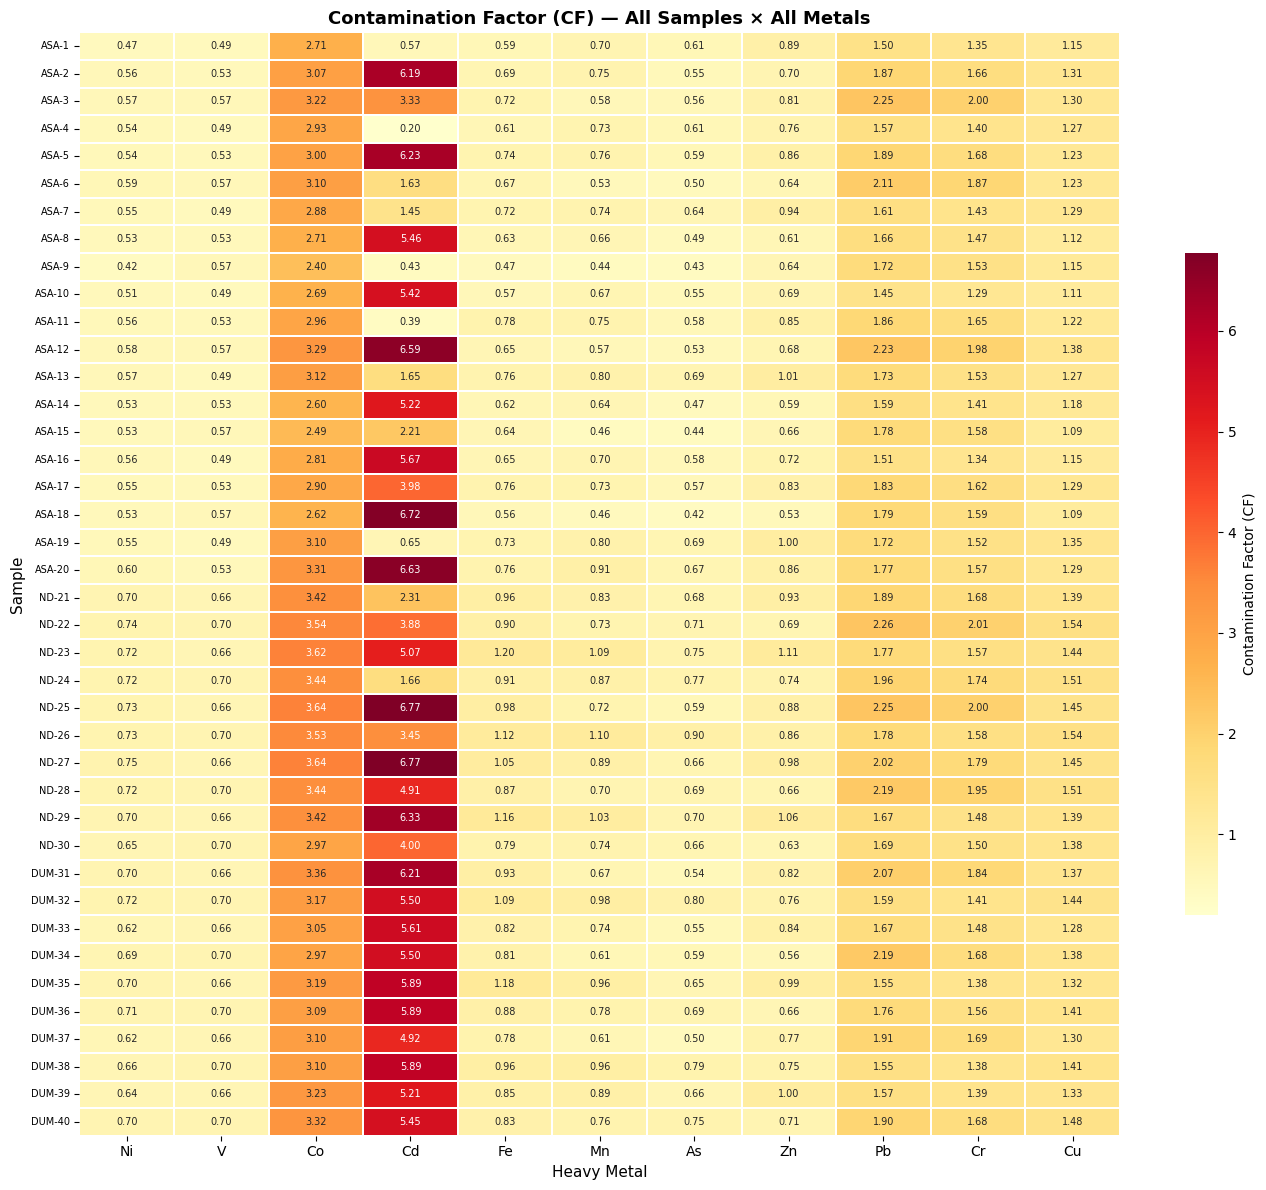

✅ Saved: heatmap_CF.svg


In [28]:
# ── CELL 18: CF heatmap all samples × all metals ─────────────────────────────
import seaborn as sns

cf_pivot = cf_df[['Sample'] + [f'CF_{m}' for m in metals]].set_index('Sample')
cf_pivot.columns = metals

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cf_pivot, cmap='YlOrRd', linewidths=0.3, linecolor='white',
            annot=True, fmt='.2f', annot_kws={'size': 7},
            cbar_kws={'label': 'Contamination Factor (CF)', 'shrink': 0.6},
            ax=ax)
ax.set_title('Contamination Factor (CF) — All Samples × All Metals',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Heavy Metal', fontsize=11)
ax.set_ylabel('Sample', fontsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig('heatmap_CF.svg', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: heatmap_CF.svg")

In [29]:
# ── CELL 19: Output file checklist ───────────────────────────────────────────
import os

files = [
    'descriptive_statistics.xlsx',
    'contamination_factor.xlsx',
    'geoaccumulation_index.xlsx',
    'enrichment_factor.xlsx',
    'pollution_load_index.xlsx',
    'exposure_doses_ADD.xlsx',
    'hazard_quotient_HQ_HI.xlsx',
    'carcinogenic_risk_CR.xlsx',
    'heatmap_CF.svg',
] + [f'distribution_{m}.svg'     for m in metals] \
  + [f'distribution_log_{m}.svg' for m in metals] \
  + [f'boxplot_{m}.svg'          for m in metals] \
  + [f'HQ_bar_{pop}.svg'         for pop in ['Adults','Children']]

print("\n📁 Output files:")
print("═"*60)
for f in files:
    status = '✅' if os.path.exists(f) else '⚠️  not yet saved'
    print(f"  {status}  {f}")
print("═"*60)


📁 Output files:
════════════════════════════════════════════════════════════
  ✅  descriptive_statistics.xlsx
  ✅  contamination_factor.xlsx
  ✅  geoaccumulation_index.xlsx
  ✅  enrichment_factor.xlsx
  ✅  pollution_load_index.xlsx
  ✅  exposure_doses_ADD.xlsx
  ✅  hazard_quotient_HQ_HI.xlsx
  ✅  carcinogenic_risk_CR.xlsx
  ✅  heatmap_CF.svg
  ✅  distribution_Ni.svg
  ✅  distribution_V.svg
  ✅  distribution_Co.svg
  ✅  distribution_Cd.svg
  ✅  distribution_Fe.svg
  ✅  distribution_Mn.svg
  ✅  distribution_As.svg
  ✅  distribution_Zn.svg
  ✅  distribution_Pb.svg
  ✅  distribution_Cr.svg
  ✅  distribution_Cu.svg
  ✅  distribution_log_Ni.svg
  ✅  distribution_log_V.svg
  ✅  distribution_log_Co.svg
  ✅  distribution_log_Cd.svg
  ✅  distribution_log_Fe.svg
  ✅  distribution_log_Mn.svg
  ✅  distribution_log_As.svg
  ✅  distribution_log_Zn.svg
  ✅  distribution_log_Pb.svg
  ✅  distribution_log_Cr.svg
  ✅  distribution_log_Cu.svg
  ✅  boxplot_Ni.svg
  ✅  boxplot_V.svg
  ✅  boxplot_Co.svg
  ✅ 